# **On-the-fly collection of POLARIN data using OPeNDAP**
>NOTE: this notebook has been heavily inspired by the [NetCDF in Python: From beginner to pro course](https://github.com/nordatanet/NetCDF_in_Python_from_beginner_to_pro) course of Luke Marsden, and has been adjusted to suit the needs of the Transnational Access (TA) webinar scheduled for 9<sup>th</sup> of April 2026 10:00 - 10:45 CEST.

# Welcome to the POLARIN TA webinar mini-walkthrough for data usage in POLARIN!
This notebook demonstrates how to collect and visualize data from POLARIN datasets by leveraging the power of data access protocols (DAPs). Firstly, DAPs will be introduced by giving the example of OPeNDAP, after which we will continue into ERDDAP, which is should (currently) be used to access POLARIN-specific datasets. Because OPeNDAP is  are planning to provide 

## An introduction into on-the-fly data access through DAPs
DAPs are widely utilized both to access and to provide data over the internet. They allow data users can directly request and retrieve data from globally dispersed, multi-domain data providers that run DAP servers, eliminating the need for massive or even size-prohibitive data downloads. Users can then manipulate and perform analyses on these data in a standardized manner, often allowing for easy integration into popular data science tools, such as Matlab, IDL, R, Panoply, and/or Python. 

### How do DAPs work?

1. **Data Servers**: Institutions host servers with DAP technologies that provide access to their datasets.
2. **Client Tools**: Users connect to these servers using DAP-compatible software (e.g., Python libraries like `pydap`, or tools like Panoply).
3. **Data Requests**: Users request specific data subsets, which are then delivered over the internet in a usable format.

<center><img src="../../sources/images/OPeNDAP-infographic.png" height="auto">

Functioning of DAPs, exemplified here with functioning of OPeNDAP. Source: <a href="https://www.opendap.org/" target="_blank">OPeNDAP website</a>. Last accessed 09-04-2026.</center>

### What can a DAP do for the data provider (data centers and repositories)?
The implementation and use of DAPs has the following main advantages for data providers (data centers and repositories):

- **Standardized Access**: Provides a uniform, protocol-based way for users to access data, reducing compatibility issues.
- **Bandwidth Efficiency**: Enables users to gather and lazily load only the data needed for on-the-fly data transformation and analysis. This significantly reduces the amount of download requests and subsequently lowers server load and costs.
- **Cloud-Friendly**: Compatible with cloud storage and cloud-optimized data formats like NetCDF4 and Zarr, enabling scalable and flexible infrastructure.
- **Cost-Efficiency**: Allows to dynamically adjust resources based on traffic, with pay-as-you-go pricing and resource scaling.
- **Flexibility**: Allows for hybrid architecture, where the server runs in the cloud while data is stored on-premises or in a mix of cloud and local storage.
- **Community Collaboration**: Encourages data sharing and collaboration within the scientific community.
- **FAIR compliance**: Aligns with FAIR data principles, supporting open science and funding requirements. More specifically, DAPs provide a searchable endpoint and promotes the use of popular (meta)data standards and persistent identifiers (PIDs) (promoting Findability); an open access protocol and lazy loading (on-the-fly subsetting) of data (promoting Accessibility); and support for multiple formats and tools that enable seamless data integration and analysis (promoting Interoperability).

### What can a DAP do for the data user (you)?
But it also provides many advantages for data users, like:
- **Enhances cross-discipline interoperability**: Works seamlessly with popular data analysis tools (e.g. Python, R, MATLAB) and supports multiple data formats.
- **Efficiency and Flexibility**: Users can instantly access only the data they need (e.g., specific variables, time ranges, or regions) without downloading full datasets, saving time, bandwidth, and storage while enabling real-time customization and seamless integration with analysis tools.
- **Automated workflows**: Supports user automation using aforementioned tools, reducing the need for manual operations.
- **On-the-Fly data processing**: Eliminates the need for manual pre-processing, allowing users to dynamically generate tailored data products and focus on analysis rather than data management.

Today, we will focus several technologies that directly bridge between data provider and consumer, including OPeNDAP (Open-source Project for a Network Data Access Protocol) and ERDDAP (Environmental Research Division Data Access Program). We will also go into using constraint expressions syntax to directly subset remotely-served datasets using customized URL requests.

## Using OPeNDAP for interactive data access
### What is OPeNDAP?
<img src="../../sources/images/OPENDAP.png" width="500" height="auto">

OPeNDAP logo. Source: <a href="https://www.opendap.org/" target="_blank"> OPeNDAP website</a>. Last accessed 09-04-2026.

**OPeNDAP** is a DAP that is widely used in Earth science, oceanography, meteorology, and environmental research, especially in cross-discipline activities. It is the DAP that is used in the xarray Python module, although it doesn't gain much credit for it's wide adoption.

### What makes OPeNDAP stand out from other DAPs?

- **Remote Data Access**: OPeNDAP enables users to access data distributed across scattered remote servers as if it were local, using standard protocols like HTTP.
- **Interoperability**: OPeNDAP supports a variety of data formats, including NetCDF, HDF, and ASCII, making it versatile for different types of scientific data.
- **Open Standards**: Built on open standards, OPeNDAP promotes data sharing and collaboration across institutions and disciplines.

### Accessing a POLARIN dataset using OPeNDAP
Let's start by importing the necessary libraries.

In [ ]:
# Import xarray for handling multi-dimensional arrays after accessing them via either ERDDAP or OPeNDAP.
import xarray as xr

# Import matplotlib for plotting the data.
import matplotlib.pyplot as plt

That is the only library to be imported for now, as we won't be visualizing the datasets for now. Let's start by searching which research data we want to investigate. As a part of this tutorial, we provide you with an exemplary OPeNDAP URL directly, but this workflow works with any data served through OPeNDAP compatible machine-readable interfaces. The example given here can be seen as a dataset with high FAIR-compliance and level of interoperability.

We will investigate the structure of a dataset from the Weather Station HORNSUND (MET station number 'SN99754') managed by the Norwegian Meteorological Institute (MET). These data are made available through the Svalbard Integrated Arctic Earth Observing System (SIOS) Data Management System (SDMS), and can be accessed via their [Data Access Portal](https://sios-svalbard.org/metsis/search). 

### Importing the dataset

In [2]:
# Load the dataset directly from the OPeNDAP URL
url = "https://thredds.met.no/thredds/dodsC/arcticdata/frost2netcdf-fixed/SN99754/SN99754-aggregated.ncml"
ds = xr.open_dataset(url)
ds

<xarray.Dataset> Size: 7MB
Dimensions:                                (time: 144600)
Coordinates:
  * time                                   (time) datetime64[ns] 1MB 2009-11-...
Data variables:
    surface_air_pressure                   (time) float32 578kB ...
    air_temperature                        (time) float32 578kB ...
    relative_humidity                      (time) float32 578kB ...
    dew_point_temperature                  (time) float32 578kB ...
    wind_from_direction                    (time) float32 578kB ...
    battery_voltage                        (time) float32 578kB ...
    wind_speed                             (time) float32 578kB ...
    air_pressure_at_sea_level_qnh          (time) float32 578kB ...
    air_pressure_at_sea_level              (time) float32 578kB ...
    tendency_of_surface_air_pressure_type  (time) float32 578kB ...
Attributes: (12/34)
    title:                    Weather station HORNSUND (SN99754)
    featureType:              timeSeries
    summary:                  Information from the station HORNSUND with MET ...
    keywords:                 GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC...
    keywords_vocabulary:      GCMDSK:GCMD Science Keywords:https://gcmd.earth...
    license:                  https://creativecommons.org/licenses/by/4.0/leg...
    ...                       ...
    MET_Identifier:           SN99754
    project:                  Public Service, Arctic PASSION, APPLICATE, SIOS...
    collection:               SIOS, SIOSCD
    activity_type:            In Situ Land-based station
    iso_topic_category:       climatologyMeteorologyAtmosphere
    id:                       no.met.adc:d3d2e163-aa3e-591c-9897-6ccd4bfe3bce

### Investigating the dataset
Let’s start by looking at the global attributes of the dataset. These are often refered to as 'discovery (level) metadata'. These are the metadata that describe the file as a whole. Below you can access them into a python dictionary.

In [3]:
print("\nDataset attributes:")  
ds.attrs


Dataset attributes:


{'title': 'Weather station HORNSUND (SN99754)',
 'featureType': 'timeSeries',
 'summary': 'Information from the station HORNSUND with MET station number SN99754.  Data are extracted from FROST, the API for the observation database of the Norwegian Meteorological Institute. Data are extracted and converted to CF-NetCDF. In this database, data are received in real time, and quality controlled.',
 'keywords': 'GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC PRESSURE > SURFACE PRESSURE, GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC TEMPERATURE > SURFACE TEMPERATURE > AIR TEMPERATURE, GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC WATER VAPOR > WATER VAPOR INDICATORS > HUMIDITY > RELATIVE HUMIDITY, GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC WATER VAPOR > WATER VAPOR INDICATORS > DEW POINT TEMPERATURE, GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC WINDS > SURFACE WINDS > WIND DIRECTION, GCMDSK:, GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC WINDS > SURFACE WINDS > WIND SPEED, GCM

To extract only the dimensions of the dataset, you can do this:

In [4]:
print("\nDataset dimensions:")  
ds.sizes


Dataset dimensions:


Frozen({'time': 144600})

Dimensions tell you about the shape and size of your variables. In this case, we know that any variable with a dimension of only _time_ will have 144600 data points - though some could be NaN. 

This dataset seems to have only one dimension. If there would be multiple, individual dimensions can be accessed like this:

In [5]:
ds.sizes['time']

144600

Let's continue by looking at the variables and coordinates of the dataset. Variables are where the data or coordinate values are stored. The coordinate variables usually have the same names as their respective dimensions. 

So to recap, a dimension tells you how many grid points there are, whilst the coordinate variable tells you the values for those grid points. To extract all the coordinate variables at once, we can do this:

In [6]:
print("\nDataset coordinates:")  
ds.coords


Dataset coordinates:


Coordinates:
  * time     (time) datetime64[ns] 1MB 2009-11-01 ... 2026-04-30T23:00:00

The name of the variable is given first.

The dimension (or dimensions) that the variable has is second in brackets. So a variable with 2 dimensions will contain a 2D grid of values, where the size of grid can be seen by looking at the dimensions.

Third is the format that the values are stored in. datetime64 tells you the values are in standardized 64-bit datetime format that is widely used in NumPy and Pandas to represent dates and times. Awesome!

The data variables can be extracted like this:

In [7]:
ds.data_vars

Data variables:
    surface_air_pressure                   (time) float32 578kB ...
    air_temperature                        (time) float32 578kB ...
    relative_humidity                      (time) float32 578kB ...
    dew_point_temperature                  (time) float32 578kB ...
    wind_from_direction                    (time) float32 578kB ...
    battery_voltage                        (time) float32 578kB ...
    wind_speed                             (time) float32 578kB ...
    air_pressure_at_sea_level_qnh          (time) float32 578kB ...
    air_pressure_at_sea_level              (time) float32 578kB ...
    tendency_of_surface_air_pressure_type  (time) float32 578kB ...

To extract a single variable named 'air_temperature':

In [8]:
ds.data_vars['air_temperature']

<xarray.DataArray 'air_temperature' (time: 144600)> Size: 578kB
[144600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1MB 2009-11-01 ... 2026-04-30T23:00:00
Attributes:
    long_name:             air temperature
    standard_name:         air_temperature
    units:                 degC
    performance_category:  C - The sensor type is assumed to fulfill the WMO/...
    _ChunkSizes:           744

Above you can see not only the data values but also the variable attributes, which are the metadata describing that variable.

To extract only the data values themselves:

In [9]:
ds.data_vars['air_temperature'].values

array([nan, nan, nan, ..., nan, nan, nan], shape=(144600,), dtype=float32)

You can see that the array is rather long with its 144600 data entries, so it does not display the entire array. 

Alternatively, you can load in just the attributes:

In [10]:
ds['air_temperature'].attrs

{'long_name': 'air temperature',
 'standard_name': 'air_temperature',
 'units': 'degC',
 'performance_category': 'C - The sensor type is assumed to fulfill the WMO/CIMO requirements. Missing measurement for control, rutines for calibration, or maintanence.',
 '_ChunkSizes': np.int32(744)}

The attributes are retrieved as a dictionary, so it is possible to access a single attribute by calling the key or attribute name:

In [11]:
ds['air_temperature'].attrs['standard_name']

'air_temperature'

## Data analysis: Weather data
What was the weather like in Hornsund last month (March 2026)? This is the most recent data as the dataset is only updated every month.

Let's check it! Start by subsetting the data:

In [29]:
weather_data = ds.sel(time=slice("2026-03-01","2026-03-29"))
weather_data

<xarray.Dataset> Size: 33kB
Dimensions:                                (time: 696)
Coordinates:
  * time                                   (time) datetime64[ns] 6kB 2026-03-...
Data variables:
    surface_air_pressure                   (time) float32 3kB ...
    air_temperature                        (time) float32 3kB -2.2 ... -10.9
    relative_humidity                      (time) float32 3kB ...
    dew_point_temperature                  (time) float32 3kB ...
    wind_from_direction                    (time) float32 3kB ...
    battery_voltage                        (time) float32 3kB ...
    wind_speed                             (time) float32 3kB ...
    air_pressure_at_sea_level_qnh          (time) float32 3kB ...
    air_pressure_at_sea_level              (time) float32 3kB ...
    tendency_of_surface_air_pressure_type  (time) float32 3kB ...
Attributes: (12/34)
    title:                    Weather station HORNSUND (SN99754)
    featureType:              timeSeries
    summary:                  Information from the station HORNSUND with MET ...
    keywords:                 GCMDSK:EARTH SCIENCE > ATMOSPHERE > ATMOSPHERIC...
    keywords_vocabulary:      GCMDSK:GCMD Science Keywords:https://gcmd.earth...
    license:                  https://creativecommons.org/licenses/by/4.0/leg...
    ...                       ...
    MET_Identifier:           SN99754
    project:                  Public Service, Arctic PASSION, APPLICATE, SIOS...
    collection:               SIOS, SIOSCD
    activity_type:            In Situ Land-based station
    iso_topic_category:       climatologyMeteorologyAtmosphere
    id:                       no.met.adc:d3d2e163-aa3e-591c-9897-6ccd4bfe3bce

In [ ]:
# Select the variable to plot
variable = ds["air_temperature"]  # Replace with your variable name

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6), facecolor="#f0f0f0")

# Plot the time series
variable.plot(ax=ax, color="tab:blue", linewidth=1.5)

# Customize the plot
ax.set_title("Time Series of Air Temperature", fontsize=16, pad=20)
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Temperature (°C)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.7)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Accessing and analysing a POLARIN dataset using ERDDAP (griddap)
Using the same xarray Python library, this notebooks exemplifies the process of collecting and visualizing data a POLARIN dataset titled 'Snow Cover Fraction data from the Bayelva area near Ny-Ålesund, Svalbard'.

On top of the already-imported libraries, we need some additional libraries for this part of the tutorial.

In [12]:
# Import matplotlib for plotting both simple 2D timeseries graphs and cartographic maps of the data
import matplotlib.pyplot as plt

# Import cartopy for creating maps and visualizing geospatial data
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Importing the dataset

We start again by defining the URL of the data we want to investigate. We have gathered the following URL from the [POLARIN Data Hub Data Catalog feature](https://s4polarin.eu/data-coverage/data-catalog/) by searching for 'Bayelva'.

Click on the download icon at the very right of the data entry, as shown in this image:

<img src="../../sources/images/SnowCover_data_DH.png" height="auto">

Gathering the snow cover data from the Bayelva area in Ny-Ålesund via the Data Hub. Source: <a href="https://s4polarin.eu/data-coverage/data-catalog/" target="_blank"> POLARIN Data Hub</a>. Last accessed 09-04-2026.

To get the URL, copy the link you are re-directed to, as shown in this image:

<img src="../../sources/images/SnowCover_data_ERDDAP_DataAccessForm_URL.png" height="auto">

Gathering the URL for accessing the snow cover data from the Bayelva area in Ny-Ålesund via ERDDAP. Source: <a href="https://erddap.s4polarin.eu/erddap-cnr/erddap/tabledap/cnr_iadc_aa28_010e_cd20.html" target="_blank"> POLARIN ERDDAP</a>. Last accessed 09-04-2026.

We have to deconstruct the URL a bit to structure them as an OPeNDAP request that works with xarray. Simply remove the '.html' extension of the URLs, to get a direct reference to the dataset, and not its landing page. Let's load in the data now!

In [13]:
# Dataset 1: Snow Cover in Bayelva area
snow_url = 'https://data.iadc.cnr.it/erddap/griddap/salzano_fractional'

snow_ds = xr.open_dataset(snow_url)
snow_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 1340, Y: 469, X: 672)
Coordinates:
  * time     (time) datetime64[ns] 11kB 2020-01-01T12:00:00 ... 2023-12-31T13...
  * Y        (Y) float64 4kB 8.761e+06 8.761e+06 ... 8.766e+06 8.766e+06
  * X        (X) float64 5kB 4.307e+05 4.307e+05 ... 4.374e+05 4.374e+05
Data variables:
    fsca     (time, Y, X) int32 2GB ...
Attributes: (12/72)
    _NCProperties:                                  version=1|netcdflibversio...
    acknowledgment:                                 The dataset is provided i...
    cdm_data_type:                                  Grid
    cdm_timeseries_variables:                       time
    character_encoding:                             utf8
    comment:                                        JC Gallet supported the C...
    ...                                             ...
    time_coverage_duration:                         P1Y
    time_coverage_end:                              2023-12-31T13:00:01Z
    time_coverage_resolution:                       P1D
    time_coverage_start:                            2020-01-01T12:00:00Z
    title:                                          Fractional snow-covered a...
    topic_category:                                 imageryBaseMapsEarthCover

It seems that the snow cover map is available between January 2020 and December 2023 with a daily temporal resolution, awesome! 
Let's have a closer look at the attribute 'summary':

In [14]:
snow_ds.attrs['summary']

'The gridded datasets is a ensembled product obtained processing imagery acquired by different time-lapse cameras located at the Zeppelin Observatory, at the Gruvebadet Snow Research Site and at the Amundsen-Nobile Climate Change Tower.'

As you can see from the attribute 'summary', this dataset is an ensembled product, and therefore most likely an aggregate of multiple photos for each daily FSCA map. What the original temporal resolution of the timelapse photos was is unknown. Whether it is a daily aggregate of 1-min, 5-min, 10-min, or hourly temporal averages we can't seem to find in the discovery metadata. 

This is a good example of how a _seemingly_ detailed metadata description can still lack information that is vital for the correct interpretation of the data...!

Now that we have loaded the dataset into the xarray.Dataset() objects in our Python memory, we can start data analysis!

### Data analysis: Snow Cover data
Let's by leveraging the power of matplotlib and cartopy to plot the snow cover (FSCA) on a 2D geospatial map. This assumes you have your dataset loaded as an xarray Dataset, which we have done in the last step.

Let's say we want to see what the snow cover conditions were on the 1st of September 2021, which is in the glacier context often used to determine routes and navigation in the following winter as it gives a clear overview of potential crevassed areas and snow bridge conditions.

In [18]:
# Subset the snow dataset to the date of interest (2021-09-01)
snow_ds_subset = snow_ds.sel(time='2021-09-01', method='nearest')

# Load your dataset
fsca = snow_ds_subset['fsca']
fsca

<xarray.DataArray 'fsca' (Y: 469, X: 672)> Size: 1MB
[315168 values with dtype=int32]
Coordinates:
  * Y        (Y) float64 4kB 8.761e+06 8.761e+06 ... 8.766e+06 8.766e+06
  * X        (X) float64 5kB 4.307e+05 4.307e+05 ... 4.374e+05 4.374e+05
    time     datetime64[ns] 8B 2021-08-31T14:00:00
Attributes:
    _ChunkSizes:            1 469 672
    attribute_description:  "Area fraction" is the fraction of a grid cell's ...
    coverage_content_type:  physicalMeasurement
    grid_mapping:           UTM_projection
    long_name:              Fractional snow covered area
    short_name:             fsca
    standard_name:          snow_area_fraction_viewable_from_above
    units:                  1
    valid_max:              100
    valid_min:              0

To georeference the basemap later, we need to extract the geospatial boundaries of the data from the discovery metadata, stored in the dataset attributes!

In [19]:
# Extract the geospatial_bounds attribute
geospatial_bounds = snow_ds.attrs['geospatial_bounds']

# Use string manipulation to extract the coordinate values
import re

# Extract the numbers from the string
coordinates = re.findall(r"[-+]?\d*\.\d+|\d+", geospatial_bounds)

# Convert the extracted strings to floats
lat_lon_bounds = [float(coord) for coord in coordinates]

# Separate the latitude and longitude bounds
lat_bounds = [lat_lon_bounds[0], lat_lon_bounds[2]]
lon_bounds = [lat_lon_bounds[1], lat_lon_bounds[3]]

print("Latitude bounds:", lat_bounds)
print("Longitude bounds:", lon_bounds)

Latitude bounds: [78.92, 79.0]
Longitude bounds: [11.93, 12.0]


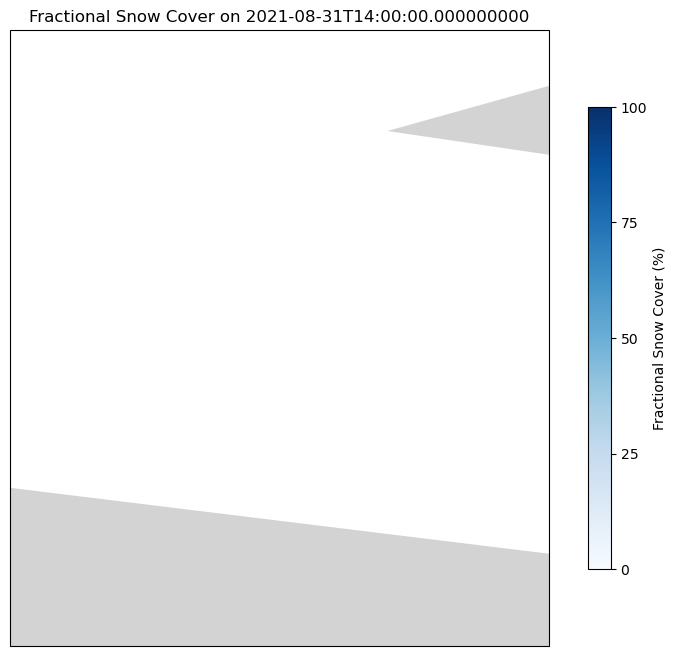

In [17]:
# Create a figure and axis with a Plate Carree projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the snow cover data
im = ax.pcolormesh(snow_ds_subset.X, snow_ds_subset.Y, fsca, transform=ccrs.PlateCarree(), cmap='Blues', shading='auto', vmin=0, vmax=100)

# Make sure the map is focused on the area of interest
ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Add a colorbar with the range 0 to 100% and appropriate ticks
cbar = plt.colorbar(im, ax=ax, orientation='vertical', label='Fractional Snow Cover (%)', shrink=0.75)
cbar.set_ticks([0, 25, 50, 75, 100])

# Set the title with automatic date formatting
ax.set_title('Fractional Snow Cover on ' + str(snow_ds_subset.time.values))

# Show the plot
plt.show()

>NOTE: It seems that this datasets is erroneous, as there are no values in the dataset, not even NaN. This is to be fixed with the data provider. 

# Congratulations!

You've successfully fetched and visualized data from a POLARIN dataset. This demonstrates how to:
1. Use DAPs to your advantage 
2. Access data from OPeNDAP servers and more specifically, POLARIN's ERDDAP server
3. Subsetting the data by fetching specific variables and time periods before loading the data into memory
4. Create a simple visualization of the data

<img src="https://ocean-ice.eu/wp-content/uploads/2025/02/TO-USE-RGB-for-digital-materials-V.png" width="250"/>

<img src="https://eu-polarin.eu/wp-content/uploads/2024/04/polarin-web1.svg" width="500"/>
